# Healthcare Prediction System

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [166]:
# Load Dataset
df = pd.read_csv(r"C:\Users\amans\Downloads\healthcare_disease_prediction_dataset.csv")
df.head()



,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0


In [138]:
# Data Information
print("\nDataset Info:")
print(df.info())




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   object 
 2   Blood Pressure       1000 non-null   object 
 3   Cholesterol          1000 non-null   object 
 4   Glucose              1000 non-null   object 
 5   Smoking              1000 non-null   object 
 6   Alcohol Consumption  1000 non-null   object 
 7   Exercise             1000 non-null   object 
 8   BMI                  1000 non-null   float64
 9   Family History       1000 non-null   object 
 10  Heart Disease        1000 non-null   int64  
 11  Diabetes             1000 non-null   int64  
 12  Stroke               1000 non-null   int64  
 13  Kidney Disease       1000 non-null   int64  
 14  Cancer               1000 non-null   int64  
 15  Alzheimer's Disease  100

In [139]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
               Age          BMI  Heart Disease     Diabetes       Stroke  \
count  1000.000000  1000.000000    1000.000000  1000.000000  1000.000000   
mean     52.881000    29.213037       0.253000     0.186000     0.134000   
std      20.958915     6.196368       0.434948     0.389301     0.340823   
min      18.000000    18.504881       0.000000     0.000000     0.000000   
25%      34.750000    23.924004       0.000000     0.000000     0.000000   
50%      52.500000    28.892349       0.000000     0.000000     0.000000   
75%      71.000000    34.663806       1.000000     0.000000     0.000000   
max      89.000000    39.974048       1.000000     1.000000     1.000000   

       Kidney Disease      Cancer  Alzheimer's Disease        COPD  \
count     1000.000000  1000.00000          1000.000000  1000.00000   
mean         0.142000     0.10000             0.130000     0.10100   
std          0.349225     0.30015             0.336472     0.30148   
min          

In [ ]:
# Handling Missing Va

In [168]:
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())




Missing Values:
 Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
Diabetes               0
Stroke                 0
Kidney Disease         0
Cancer                 0
Alzheimer's Disease    0
COPD                   0
Liver Disease          0
Parkinson's Disease    0
Tuberculosis           0
dtype: int64


In [169]:
df.fillna(0)

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,796,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,926,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,16,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,147,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,882,No,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,Female,Low,High,Normal,No,No,No,635,Yes,1,0,0,0,0,0,0,0,0,0
996,51,Female,High,High,Normal,No,Yes,Yes,73,Yes,0,0,0,0,0,0,0,0,0,0
997,72,Female,Normal,High,Normal,Yes,No,No,105,Yes,0,0,0,0,0,0,0,0,0,0
998,49,Male,Normal,High,High,Yes,No,Yes,40,Yes,0,0,0,0,0,1,0,0,0,0


In [170]:
# Remove duplicates
df.drop_duplicates(inplace=False)

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,796,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,926,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,16,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,147,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,882,No,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,Female,Low,High,Normal,No,No,No,635,Yes,1,0,0,0,0,0,0,0,0,0
996,51,Female,High,High,Normal,No,Yes,Yes,73,Yes,0,0,0,0,0,0,0,0,0,0
997,72,Female,Normal,High,Normal,Yes,No,No,105,Yes,0,0,0,0,0,0,0,0,0,0
998,49,Male,Normal,High,High,Yes,No,Yes,40,Yes,0,0,0,0,0,1,0,0,0,0


# Label Encoder

In [167]:
le = LabelEncoder()

df['BMI'] = le.fit_transform(df['BMI'])
le

LabelEncoder()

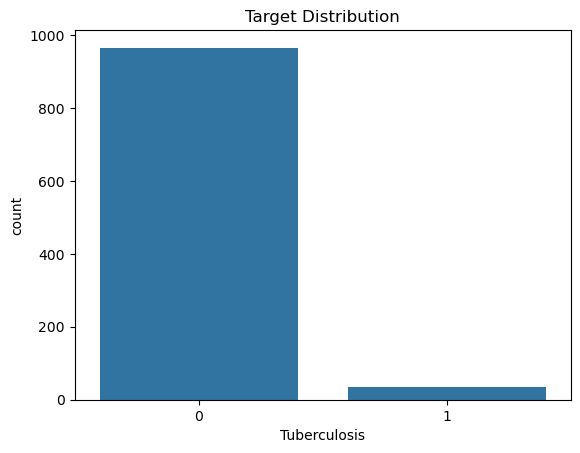

In [143]:
# Target distribution (assume last column is disease)
target_column = df.columns[-1]

plt.figure()
sns.countplot(x=df[target_column])
plt.title("Target Distribution")
plt.show()



# Histogram

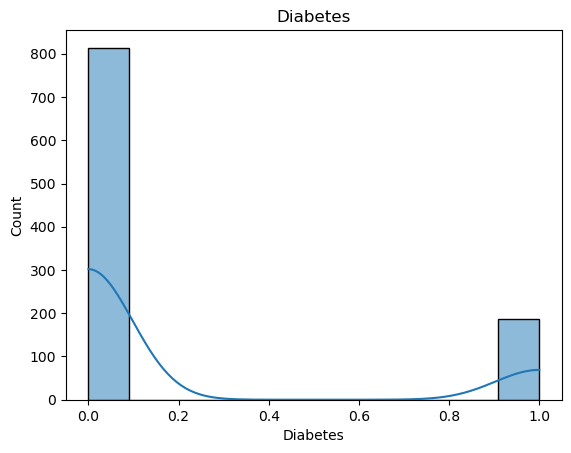

In [183]:
# Price Distribution

sns.histplot(df['Diabetes'], kde=True)
plt.title("Diabetes")
plt.show()

# Scatterplot

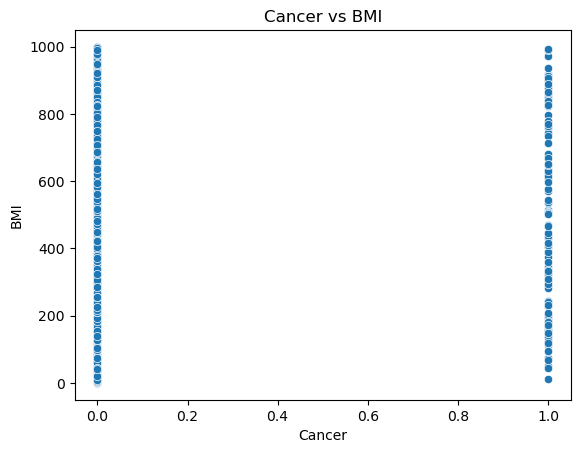

In [184]:
# living Area and Price

sns.scatterplot(x='Cancer', y='BMI', data=df)
plt.title("Cancer vs BMI")
plt.show()

# Categorical data

In [146]:
# Convert categorical to numeric
df = pd.get_dummies(df)



In [147]:
# Features & Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [149]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
scaler

StandardScaler()

In [150]:
X_train , X_test

(array([[ 0.92076243,  1.65333454, -0.56772709, ...,  1.03823026,
         -1.03823026, -1.01257911],
        [-0.75596416, -1.04989291, -0.56772709, ...,  1.03823026,
         -1.03823026, -1.01257911],
        [ 0.96866891,  0.75653042, -0.56772709, ..., -0.96317747,
          0.96317747,  0.98757716],
        ...,
        [ 1.01657538,  0.09536307, -0.56772709, ..., -0.96317747,
          0.96317747, -1.01257911],
        [ 0.63332359,  0.18032783, -0.56772709, ...,  1.03823026,
         -1.03823026,  0.98757716],
        [ 0.53751064,  0.7572329 , -0.56772709, ...,  1.03823026,
         -1.03823026,  0.98757716]]),
 array([[ 0.96866891,  0.18777903, -0.56772709, ...,  1.03823026,
         -1.03823026, -1.01257911],
        [ 0.82494949,  1.67806525,  1.76140969, ...,  1.03823026,
         -1.03823026, -1.01257911],
        [ 1.63935955,  0.76758008, -0.56772709, ...,  1.03823026,
         -1.03823026, -1.01257911],
        ...,
        [-1.6182807 ,  0.96675759, -0.56772709, ..., -

# Linear Regression

In [152]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_model

LinearRegression()

In [153]:
y_pred_lr = lr_model.predict(X_test)
y_pred_lr = np.round(y_pred_lr)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Linear Regression Accuracy:", acc_lr)


Linear Regression Accuracy: 1.0
[[ 92   0]
 [  0 108]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        92
        True       1.00      1.00      1.00       108

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [154]:
print(confusion_matrix(y_test, y_pred_lr))


[[ 92   0]
 [  0 108]]


In [155]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00        92
        True       1.00      1.00      1.00       108

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# K Nearest Neighbour

In [156]:
#k nearest neighbour
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_model

KNeighborsClassifier()

In [157]:
y_pred_knn = knn_model.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", acc_knn)


KNN Accuracy: 0.905


In [158]:
print(confusion_matrix(y_test, y_pred_knn))


[[ 81  11]
 [  8 100]]


In [159]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       False       0.91      0.88      0.90        92
        True       0.90      0.93      0.91       108

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200



# Support Vector Machine

In [160]:
#svm
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
svm_model

SVC(kernel='linear')

In [161]:
y_pred_svm = svm_model.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)


SVM Accuracy: 1.0


In [162]:
print(confusion_matrix(y_test, y_pred_svm))

[[ 92   0]
 [  0 108]]


In [163]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00        92
        True       1.00      1.00      1.00       108

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# Model Accuracy Coprasion

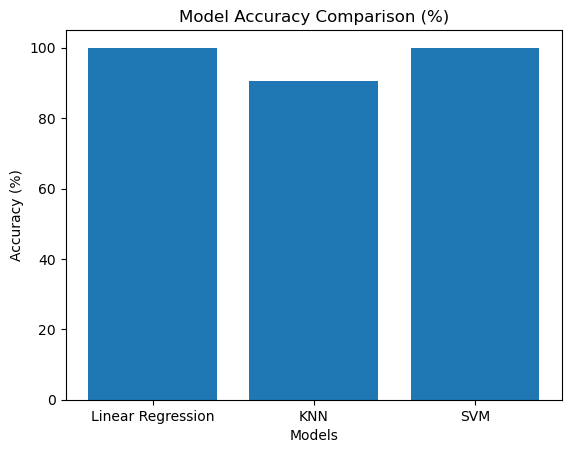


Final Accuracy Comparison:
Linear Regression: 100.00%
KNN: 90.50%
SVM: 100.00%


In [84]:
models = ['Linear Regression', 'KNN', 'SVM']
accuracies = [lr_accuracy, knn_accuracy, svm_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison (%)")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.show()

print("\nFinal Accuracy Comparison:")
for model, acc in zip(models, accuracies):
    print(f"{model}: {acc:.2f}%")